# Credit Risk Scorecard: Predicting Loan Default
**Author:** Hiral Prajapati

**Business problem:** A lender receives thousands of loan applications. Approving borrowers who later default costs money; rejecting good borrowers loses revenue. The goal is to **predict the probability that an applicant will default (PD)** and turn it into a **credit score** the lender can use to approve or decline.

**Data:** 163,987 real Lending Club personal loans (US peer-to-peer lender), each labelled as repaid (`bad_loan = 0`) or defaulted/charged off (`bad_loan = 1`).

**Approach**
1. Explore the data and understand what drives default
2. Clean the data and prepare features
3. Measure each feature's predictive power with **Weight of Evidence (WoE)** and **Information Value (IV)**, the standard method in bank credit risk
4. Build a **logistic regression scorecard** (the industry standard, because regulators require explainable models)
5. Compare it with a **gradient boosting** machine learning model
6. Evaluate with **AUC, Gini and KS**, the metrics banks use
7. Translate the model into a **business decision**: where to set the approval cut-off

## 1. Setup and load the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
Path("images").mkdir(exist_ok=True)

# Load locally if available, otherwise download the public copy of the Lending Club data
LOCAL = Path("data/loan.csv")
URL = "https://raw.githubusercontent.com/h2oai/app-consumer-loan/master/data/loan.csv"
df = pd.read_csv(LOCAL if LOCAL.exists() else URL)
print(f"{df.shape[0]:,} loans, {df.shape[1]} columns")
df.head()

163,987 loans, 15 columns


,loan_amnt,term,int_rate,emp_length,home_ownership,annual_inc,purpose,addr_state,dti,delinq_2yrs,revol_util,total_acc,bad_loan,longest_credit_length,verification_status
0,5000,36 months,10.650,10.000,RENT,"24,000.000",credit_card,AZ,27.650,0.000,83.700,9.000,0,26.000,verified
1,2500,60 months,15.270,0.000,RENT,"30,000.000",car,GA,1.000,0.000,9.400,4.000,1,12.000,verified
2,2400,36 months,15.960,10.000,RENT,"12,252.000",small_business,IL,8.720,0.000,98.500,10.000,0,10.000,not verified
3,10000,36 months,13.490,10.000,RENT,"49,200.000",other,CA,20.000,0.000,21.000,37.000,0,15.000,verified
4,5000,36 months,7.900,3.000,RENT,"36,000.000",wedding,AZ,11.200,0.000,28.300,12.000,0,7.000,verified


## 2. Understand the data
First question in any credit project: **what is the overall default rate?** This is the baseline every model must beat.

In [2]:
TARGET = "bad_loan"
print(f"Overall default rate: {df[TARGET].mean():.1%}")
print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

Overall default rate: 18.3%

Missing values per column:
emp_length               5804
annual_inc                  4
delinq_2yrs                29
revol_util                193
total_acc                  29
longest_credit_length      29
dtype: int64


**Default rate by loan characteristics.** If a feature splits borrowers into groups with very different default rates, it is useful for prediction.

In [3]:
def default_rate_by(col):
    return (df.groupby(col)[TARGET].agg(loans="count", default_rate="mean")
              .sort_values("default_rate", ascending=False))

display(default_rate_by("term"))
display(default_rate_by("purpose"))

,loans,default_rate
term,,
60 months,34037,0.295
36 months,129950,0.154


,loans,default_rate
purpose,,
small_business,3841,0.309
renewable_energy,198,0.227
other,10492,0.214
educational,418,0.211
moving,1464,0.208
medical,2029,0.203
debt_consolidation,93261,0.189
house,1245,0.182
vacation,1096,0.179


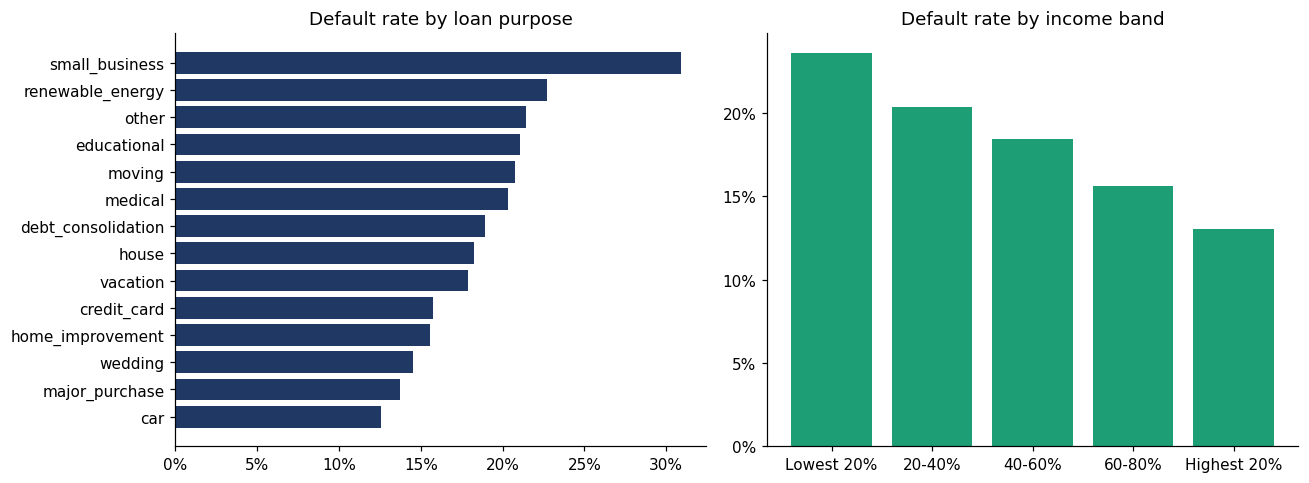

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

p = df.groupby("purpose")[TARGET].mean().sort_values()
axes[0].barh(p.index, p.values, color="#1F3864")
axes[0].set_title("Default rate by loan purpose"); axes[0].xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

inc_band = pd.qcut(df["annual_inc"], 5, labels=["Lowest 20%", "20-40%", "40-60%", "60-80%", "Highest 20%"])
i = df.groupby(inc_band, observed=True)[TARGET].mean()
axes[1].bar(i.index.astype(str), i.values, color="#1D9E75")
axes[1].set_title("Default rate by income band"); axes[1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plt.tight_layout(); plt.savefig("images/eda_default_rates.png", bbox_inches="tight"); plt.show()

**What this tells us:** small business loans default far more than car or wedding loans, 60-month loans are riskier than 36-month loans, and default falls steadily as income rises. These patterns make business sense, which is exactly what we want before modelling.

## 3. Choose features and clean the data
Two columns are deliberately **excluded**:
- **`int_rate`** is set by Lending Club *after* assessing the borrower's risk. Using it would mean copying the lender's own risk judgement instead of building ours (a form of **data leakage**).
- **`addr_state`** (US state): geography can act as a proxy for protected characteristics, which fair-lending rules restrict. It's also weakly predictive.

In [5]:
NUMERIC = ["loan_amnt", "emp_length", "annual_inc", "dti", "delinq_2yrs",
           "revol_util", "total_acc", "longest_credit_length"]
CATEGORICAL = ["term", "home_ownership", "purpose", "verification_status"]
FEATURES = NUMERIC + CATEGORICAL

data = df[FEATURES + [TARGET]].copy()

# Split BEFORE any fitting, so the test set stays truly unseen.
# stratify keeps the same default rate in both sets.
train, test = train_test_split(data, test_size=0.3, random_state=42, stratify=data[TARGET])
print(f"Train: {len(train):,} loans ({train[TARGET].mean():.1%} default)")
print(f"Test:  {len(test):,} loans ({test[TARGET].mean():.1%} default)")

Train: 114,790 loans (18.3% default)
Test:  49,197 loans (18.3% default)


Missing values are **not filled in** here. In the WoE step, missing values get their own bin, because "missing" can itself carry information (for example, missing employment length is often riskier).

## 4. Weight of Evidence (WoE) and Information Value (IV)
This is how banks build scorecards.

1. Split each feature into **bins** (for example, 10 income groups).
2. For each bin, calculate **WoE = ln(% of all good loans in the bin ÷ % of all bad loans in the bin)**.
   - Positive WoE → safer than average. Negative WoE → riskier than average.
3. Sum up **IV** across bins to measure the feature's overall predictive power:

| IV | Predictive power |
|---|---|
| < 0.02 | Useless (drop) |
| 0.02–0.1 | Weak |
| 0.1–0.3 | Medium |
| > 0.3 | Strong |

**Why WoE?** It handles missing values and outliers automatically, puts every feature on the same scale, and gives a straight-line relationship with the log-odds of default, which is exactly what logistic regression needs.

In [6]:
def fit_woe(train_df, feature, target=TARGET, n_bins=10):
    """Learn bins + WoE on the TRAINING data only. Returns a WoE table and a mapping function."""
    s = train_df[feature]
    if feature in NUMERIC:
        edges = np.unique(s.quantile(np.linspace(0, 1, n_bins + 1)).values)
        edges[0], edges[-1] = -np.inf, np.inf
        binner = lambda x: pd.cut(x, edges, include_lowest=True).astype(str).where(x.notna(), "Missing")
    else:
        binner = lambda x: x.astype(str).fillna("Missing")

    bins = binner(s)
    t = train_df.assign(bin=bins).groupby("bin")[target].agg(n="count", bad="sum")
    t["good"] = t["n"] - t["bad"]
    # +0.5 smoothing prevents dividing by zero in bins with no bads or no goods
    t["dist_good"] = (t["good"] + 0.5) / t["good"].sum()
    t["dist_bad"] = (t["bad"] + 0.5) / t["bad"].sum()
    t["default_rate"] = t["bad"] / t["n"]
    t["woe"] = np.log(t["dist_good"] / t["dist_bad"])
    t["iv"] = (t["dist_good"] - t["dist_bad"]) * t["woe"]
    if feature in NUMERIC:   # show bins in numeric order (lowest to highest), Missing last
        key = lambda b: np.inf if b == "Missing" else float(b.split(",")[0].strip("(["))
        t = t.loc[sorted(t.index, key=key)]

    woe_map = t["woe"].to_dict()
    transform = lambda x: binner(x).map(woe_map).fillna(0.0).astype(float)  # unseen bins -> neutral (0)
    return t, transform

woe_tables, transformers = {}, {}
for f in FEATURES:
    woe_tables[f], transformers[f] = fit_woe(train, f)

iv = pd.Series({f: t["iv"].sum() for f, t in woe_tables.items()}).sort_values(ascending=False)
iv_table = iv.to_frame("IV")
iv_table["power"] = pd.cut(iv, [-1, 0.02, 0.1, 0.3, 99], labels=["Useless", "Weak", "Medium", "Strong"])
iv_table

,IV,power
term,0.128,Medium
revol_util,0.076,Weak
dti,0.073,Weak
annual_inc,0.063,Weak
purpose,0.033,Weak
loan_amnt,0.026,Weak
verification_status,0.025,Weak
home_ownership,0.016,Useless
total_acc,0.012,Useless
emp_length,0.011,Useless


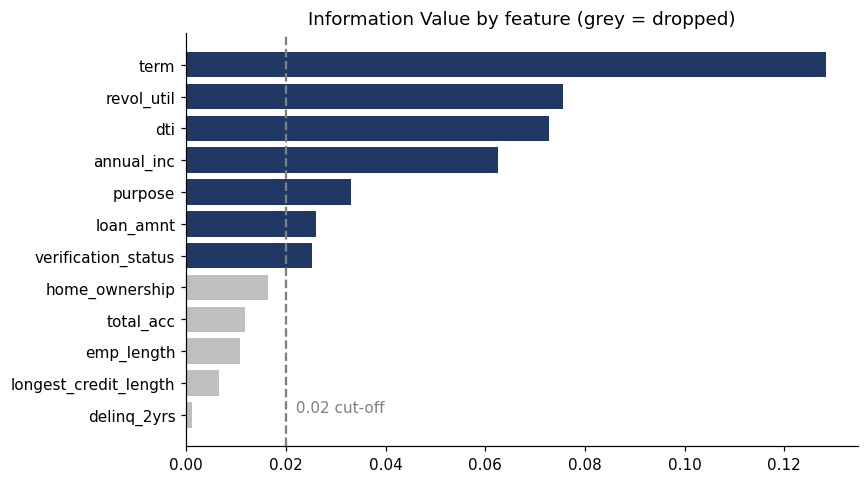

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#1F3864" if v >= 0.02 else "#BFBFBF" for v in iv.values]
ax.barh(iv.index[::-1], iv.values[::-1], color=colors[::-1])
ax.axvline(0.02, ls="--", color="grey"); ax.text(0.021, 0, " 0.02 cut-off", color="grey", va="bottom")
ax.set_title("Information Value by feature (grey = dropped)")
plt.tight_layout(); plt.savefig("images/information_value.png", bbox_inches="tight"); plt.show()

Example WoE table: **annual income**. Default rate falls and WoE rises as income increases, a clean, logical pattern.

In [8]:
woe_tables["annual_inc"][["n", "bad", "default_rate", "woe", "iv"]]

,n,bad,default_rate,woe,iv
bin,,,,,
"(-inf, 32800.0]",11482,2796,0.244,-0.362,0.015
"(32800.0, 40000.0]",11686,2683,0.230,-0.285,0.009
"(40000.0, 48000.0]",12226,2566,0.210,-0.170,0.003
"(48000.0, 55000.0]",12944,2522,0.195,-0.077,0.001
"(55000.0, 61000.0]",9155,1776,0.194,-0.072,0.000
"(61000.0, 70000.0]",12685,2267,0.179,0.029,0.000
"(70000.0, 80000.0]",11600,1872,0.161,0.152,0.002
"(80000.0, 94000.0]",10102,1528,0.151,0.229,0.004
"(94000.0, 120000.0]",12705,1728,0.136,0.353,0.012


## 5. Model 1: Logistic regression scorecard
Keep only features with IV ≥ 0.02, convert them to WoE values, and fit a logistic regression.

**Sanity check:** every coefficient should be **negative**. Higher WoE means safer, so it should reduce the probability of default. A positive coefficient usually signals a problem such as correlated features.

In [9]:
SELECTED = iv[iv >= 0.02].index.tolist()

def to_woe(frame):
    return pd.DataFrame({f: transformers[f](frame[f]) for f in SELECTED}, index=frame.index)

X_train_woe, X_test_woe = to_woe(train), to_woe(test)
y_train, y_test = train[TARGET], test[TARGET]

logit = LogisticRegression(max_iter=1000)
logit.fit(X_train_woe, y_train)

coefs = pd.Series(logit.coef_[0], index=SELECTED).sort_values()
print("Selected features:", len(SELECTED))
print("All coefficients negative:", (coefs < 0).all())
coefs.to_frame("coefficient")

Selected features: 7
All coefficients negative: True


,coefficient
annual_inc,-1.497
purpose,-1.039
loan_amnt,-0.916
revol_util,-0.899
term,-0.898
dti,-0.499
verification_status,-0.268


### Convert probability of default into a credit score
Banks present models as **points**, not probabilities, because points are easier to explain to credit committees and customers. We use the standard scaling:
- **600 points** = odds of 50 good loans to 1 bad
- **PDO = 20**: every extra 20 points doubles the odds of being a good loan

In [10]:
PDO, BASE_SCORE, BASE_ODDS = 20, 600, 50
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

def credit_score(X_woe):
    log_odds_bad = logit.intercept_[0] + X_woe.values @ logit.coef_[0]
    return offset - factor * log_odds_bad       # higher score = safer borrower

pd_logit = logit.predict_proba(X_test_woe)[:, 1]
score_test = credit_score(X_test_woe)

# Scorecard: points per feature bin (base points spread evenly across features)
n = len(SELECTED)
rows = []
for f, b in zip(SELECTED, logit.coef_[0]):
    t = woe_tables[f]
    for bin_label, w in t["woe"].items():
        pts = -(b * w + logit.intercept_[0] / n) * factor + offset / n
        rows.append({"feature": f, "bin": bin_label, "points": round(pts)})
scorecard = pd.DataFrame(rows)
scorecard[scorecard.feature == "term"]

,feature,bin,points
0,term,36 months,81
1,term,60 months,60


Reading the scorecard: a borrower's score is the **sum of points** from each feature. For example, a 36-month loan earns more points than a 60-month loan because it's historically safer.

## 6. Model 2: Gradient boosting (machine learning comparison)
Gradient boosting builds hundreds of small decision trees, each correcting the previous one's mistakes. It can capture non-linear patterns and interactions that logistic regression can't, but it's **harder to explain**, which matters in regulated lending.

In [11]:
def prep_gbm(frame):
    X = frame[FEATURES].copy()
    for c in CATEGORICAL:
        X[c] = X[c].astype("category")
    return X

X_train_gbm, X_test_gbm = prep_gbm(train), prep_gbm(test)
cats = X_train_gbm[CATEGORICAL].apply(lambda s: s.cat.categories)
for c in CATEGORICAL:   # make test use exactly the training categories
    X_test_gbm[c] = pd.Categorical(X_test_gbm[c], categories=cats[c])

gbm = HistGradientBoostingClassifier(learning_rate=0.05, max_iter=400, max_leaf_nodes=31,
                                     categorical_features="from_dtype", early_stopping=True,
                                     random_state=42)
gbm.fit(X_train_gbm, y_train)
pd_gbm = gbm.predict_proba(X_test_gbm)[:, 1]
print("Trees used:", gbm.n_iter_)

Trees used: 130


## 7. Evaluate on the unseen test set
- **AUC**: probability the model ranks a random defaulter as riskier than a random good borrower (0.5 = coin flip, 1.0 = perfect).
- **Gini = 2 × AUC − 1**: the metric banks usually quote. For application scorecards, 0.3–0.5 is typical and above 0.5 is strong.
- **KS**: the maximum separation between the cumulative distributions of goods and bads.

In [12]:
def evaluate(y, p):
    auc = roc_auc_score(y, p)
    fpr, tpr, _ = roc_curve(y, p)
    return {"AUC": auc, "Gini": 2 * auc - 1, "KS": np.max(tpr - fpr)}

results = pd.DataFrame({"Logistic scorecard": evaluate(y_test, pd_logit),
                        "Gradient boosting": evaluate(y_test, pd_gbm)}).T
results

,AUC,Gini,KS
Logistic scorecard,0.673,0.346,0.251
Gradient boosting,0.686,0.371,0.271


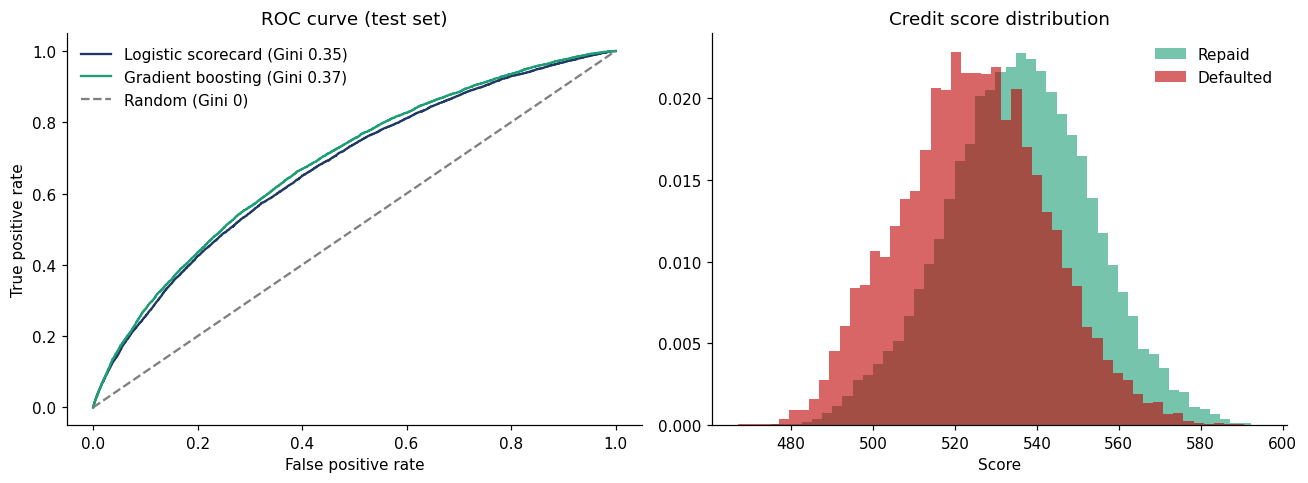

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, p, col in [("Logistic scorecard", pd_logit, "#1F3864"), ("Gradient boosting", pd_gbm, "#1D9E75")]:
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} (Gini {2*roc_auc_score(y_test, p)-1:.2f})", color=col)
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="Random (Gini 0)")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve (test set)"); axes[0].legend(frameon=False)

axes[1].hist(score_test[y_test == 0], bins=50, alpha=0.6, density=True, label="Repaid", color="#1D9E75")
axes[1].hist(score_test[y_test == 1], bins=50, alpha=0.6, density=True, label="Defaulted", color="#C00000")
axes[1].set_title("Credit score distribution"); axes[1].set_xlabel("Score"); axes[1].legend(frameon=False)
plt.tight_layout(); plt.savefig("images/roc_and_scores.png", bbox_inches="tight"); plt.show()

**Rank-ordering check.** A good scorecard must show default rates falling steadily as scores rise. Banks check this in every model validation.

Monotonic (default rate falls every band): True


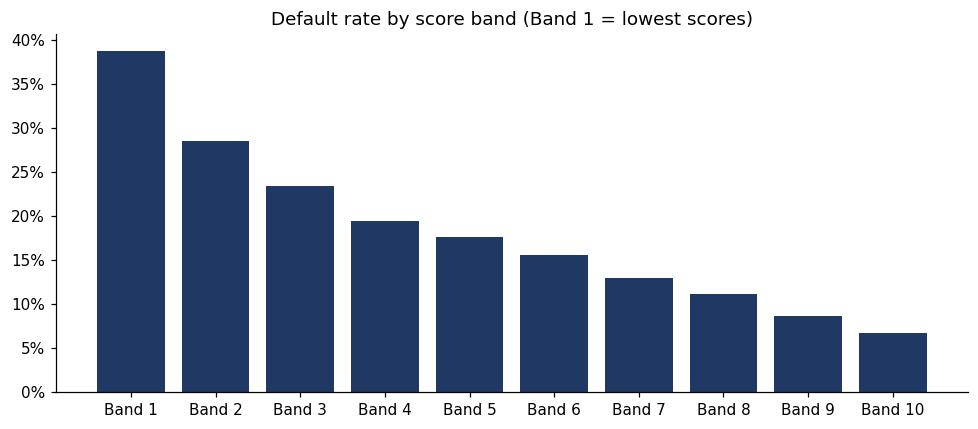

,min_score,max_score,loans,default_rate
band,,,,
Band 1,467.166,509.862,4920,0.388
Band 2,509.864,518.426,4920,0.285
Band 3,518.426,524.359,4922,0.235
Band 4,524.362,529.250,4917,0.195
Band 5,529.254,533.980,4921,0.176
Band 6,533.981,538.488,4918,0.156
Band 7,538.488,543.489,4920,0.129
Band 8,543.489,549.248,4920,0.112
Band 9,549.251,557.015,4919,0.086


In [14]:
bands = pd.qcut(score_test, 10, labels=[f"Band {i}" for i in range(1, 11)])
band_table = (pd.DataFrame({"band": bands, "score": score_test, "bad": y_test.values})
                .groupby("band", observed=True)
                .agg(min_score=("score", "min"), max_score=("score", "max"),
                     loans=("bad", "count"), default_rate=("bad", "mean")))
print("Monotonic (default rate falls every band):", band_table["default_rate"].is_monotonic_decreasing)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(band_table.index.astype(str), band_table["default_rate"], color="#1F3864")
ax.set_title("Default rate by score band (Band 1 = lowest scores)")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.tight_layout(); plt.savefig("images/default_by_band.png", bbox_inches="tight"); plt.show()
band_table

## 8. What drives the gradient boosting model?
**Permutation importance** shuffles one feature at a time and measures how much the model's AUC drops. A bigger drop means a more important feature.

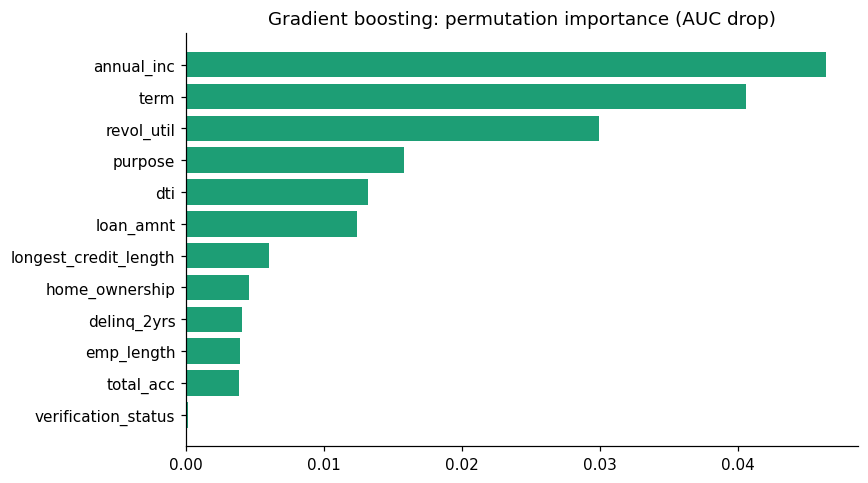

In [15]:
sample = X_test_gbm.sample(15000, random_state=42)
pi = permutation_importance(gbm, sample, y_test.loc[sample.index], scoring="roc_auc",
                            n_repeats=5, random_state=42)
importance = pd.Series(pi.importances_mean, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(importance.index, importance.values, color="#1D9E75")
ax.set_title("Gradient boosting: permutation importance (AUC drop)")
plt.tight_layout(); plt.savefig("images/feature_importance.png", bbox_inches="tight"); plt.show()

## 9. Business decision: where to set the approval cut-off?
A model only creates value when it changes decisions. Below, we simulate approving only applicants **above a score cut-off** and measure the trade-off between **approval rate** (volume/revenue) and **default rate** (losses).

In [16]:
cutoffs = np.percentile(score_test, np.arange(0, 55, 5))
rows = []
for pct, c in zip(np.arange(0, 55, 5), cutoffs):
    approved = score_test >= c
    rows.append({"decline_lowest": f"{pct}%", "score_cutoff": round(c),
                 "approval_rate": approved.mean(),
                 "default_rate_approved": y_test.values[approved].mean(),
                 "defaults_per_10k_applications": round(y_test.values[approved].sum() / len(y_test) * 10000)})
strategy = pd.DataFrame(rows)
strategy

,decline_lowest,score_cutoff,approval_rate,default_rate_approved,defaults_per_10k_applications
0,0%,467,1.000,0.183,1830
1,5%,502,0.950,0.170,1614
2,10%,510,0.900,0.160,1443
3,15%,515,0.850,0.153,1299
4,20%,518,0.800,0.145,1158
5,25%,521,0.750,0.138,1034
6,30%,524,0.700,0.132,923
7,35%,527,0.650,0.126,821
8,40%,529,0.600,0.121,728
9,45%,532,0.550,0.115,634


Approve everyone:          18.3% default rate
Decline lowest 20% scores: 14.5% default rate (score cut-off 518)
Defaults avoided per 10,000 applications: 672


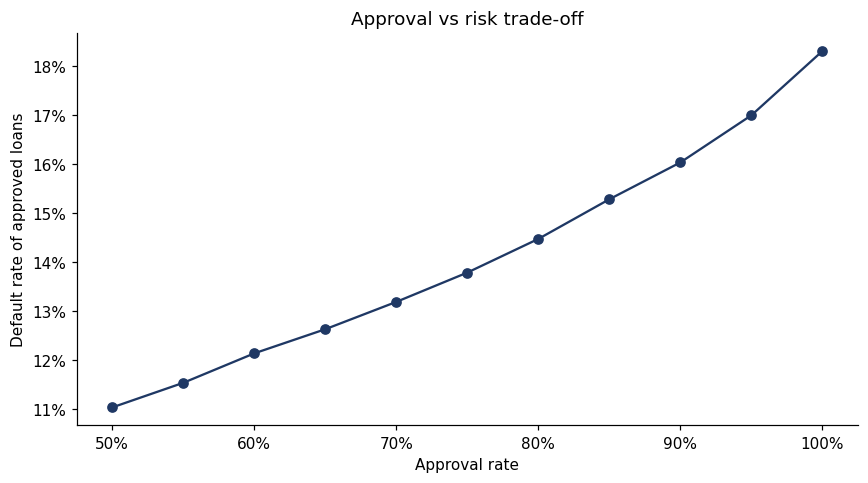

In [17]:
base = strategy.iloc[0]; s20 = strategy.iloc[4]
print(f"Approve everyone:          {base.default_rate_approved:.1%} default rate")
print(f"Decline lowest 20% scores: {s20.default_rate_approved:.1%} default rate "
      f"(score cut-off {s20.score_cutoff})")
print(f"Defaults avoided per 10,000 applications: "
      f"{base.defaults_per_10k_applications - s20.defaults_per_10k_applications:,.0f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(strategy["approval_rate"], strategy["default_rate_approved"], marker="o", color="#1F3864")
ax.set_xlabel("Approval rate"); ax.set_ylabel("Default rate of approved loans")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}"); ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_title("Approval vs risk trade-off")
plt.tight_layout(); plt.savefig("images/cutoff_tradeoff.png", bbox_inches="tight"); plt.show()

## 10. Conclusions
- The **logistic regression scorecard** ranks risk well, is fully explainable (every point can be traced to a feature bin), and has monotonic default rates across score bands. That makes it suitable for a regulated lending decision.
- **Gradient boosting** performs only slightly better. In practice, many banks would keep the scorecard for decisions and use machine learning as a challenger model, because explainability matters for regulators and customers.
- Setting a cut-off that declines the lowest-scoring 20% of applicants cuts the default rate among approved loans, with a clear trade-off against loan volume that the business can choose.

**Limitations and next steps**
- The data covers loans from 2007–2011; a real model would be validated on recent data and monitored for drift (PSI).
- Default here is a simple yes/no flag. A full **expected loss** model would add Loss Given Default (LGD) and Exposure at Default (EAD): **EL = PD × LGD × EAD**, the IFRS 9 / Basel framework.
- Bins are quantile-based; production scorecards use optimised or manually reviewed bins, and would test for multicollinearity and fairness.